In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neural_network import MLPRegressor


In [65]:
df = pd.read_csv('co2.csv')
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [66]:
print(df.isnull().sum())
print(df.describe())
print(df.dtypes)

Make                                0
Model                               0
Vehicle Class                       0
Engine Size(L)                      0
Cylinders                           0
Transmission                        0
Fuel Type                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fuel Consumption Comb (L/100 km)    0
Fuel Consumption Comb (mpg)         0
CO2 Emissions(g/km)                 0
dtype: int64
       Engine Size(L)    Cylinders  Fuel Consumption City (L/100 km)  \
count     7385.000000  7385.000000                       7385.000000   
mean         3.160068     5.615030                         12.556534   
std          1.354170     1.828307                          3.500274   
min          0.900000     3.000000                          4.200000   
25%          2.000000     4.000000                         10.100000   
50%          3.000000     6.000000                         12.100000   
75%          3.700000     6

Zamiana wartości opisowych na numeryczne za pomocą LabelEncoder

In [67]:
le = LabelEncoder()

df['marka_encoded'] = le.fit_transform(df['Make'])
df['model_encoded'] = le.fit_transform(df['Model'])
df['transmission_encoded'] = le.fit_transform(df['Transmission'])
df['fuel_type_encoded'] = le.fit_transform(df['Fuel Type'])
df['vehicle_class_encoded'] = le.fit_transform(df['Vehicle Class'])

df.drop(columns=['Make', 'Model', 'Transmission', 'Fuel Type','Vehicle Class'], inplace=True)

df.head()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),marka_encoded,model_encoded,transmission_encoded,fuel_type_encoded,vehicle_class_encoded
0,2.0,4,9.9,6.7,8.5,33,196,0,1057,14,4,0
1,2.4,4,11.2,7.7,9.6,29,221,0,1057,25,4,0
2,1.5,4,6.0,5.8,5.9,48,136,0,1058,22,4,0
3,3.5,6,12.7,9.1,11.1,25,255,0,1233,15,4,11
4,3.5,6,12.1,8.7,10.6,27,244,0,1499,15,4,11


Macierz korelacji

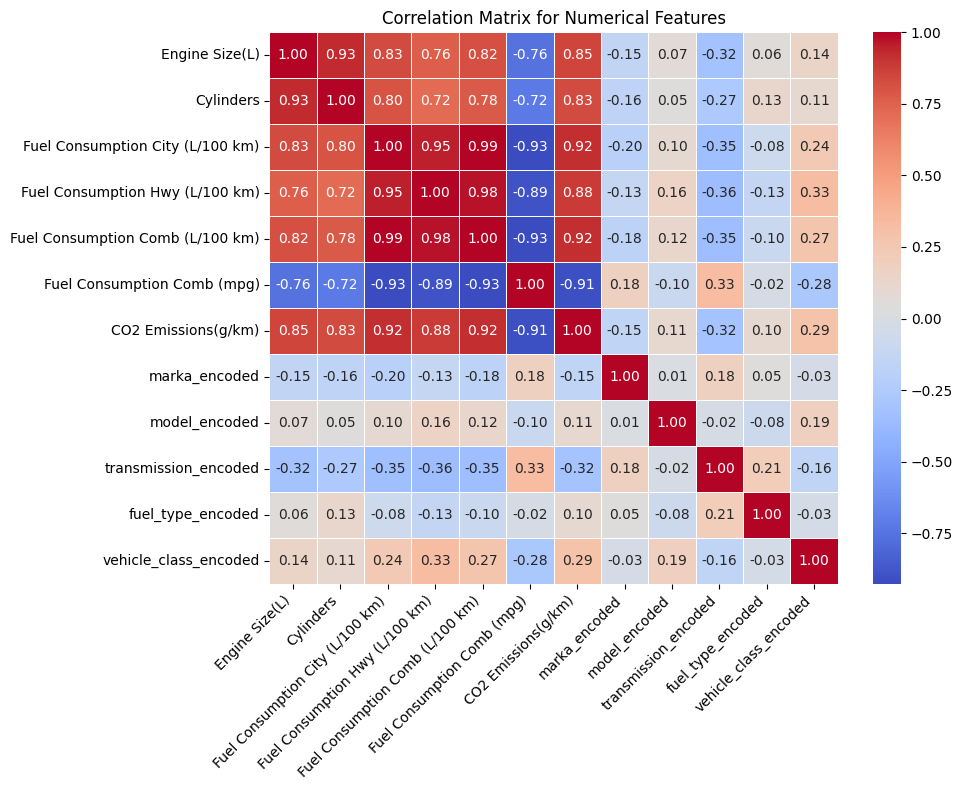

In [68]:
correlation_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix for Numerical Features")
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

Zamiana emisji CO2 na przedziały - niski, średni, wysoki, bardzo wysoki

zamiana wartości opisowych w kolumnie CO2_emission_category na numeryczne

In [69]:
min_value = df['CO2 Emissions(g/km)'].min()
max_value = df['CO2 Emissions(g/km)'].max()

bins = [min_value, 200, 250, 300, max_value+1]
labels = ['niska', 'średnia', 'wysoka', 'bardzo wysoka']
df['CO2_emission_category'] = pd.cut(df['CO2 Emissions(g/km)'], bins=bins, labels=labels, right=False)
df['CO2_emission_category_encoded'] = le.fit_transform(df['CO2_emission_category'])

df.drop(columns=['CO2_emission_category'], inplace=True)
df.drop(columns=['CO2 Emissions(g/km)'], inplace=True)

df.head()
print(df.isnull().sum())
print(df.dtypes)

Engine Size(L)                      0
Cylinders                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fuel Consumption Comb (L/100 km)    0
Fuel Consumption Comb (mpg)         0
marka_encoded                       0
model_encoded                       0
transmission_encoded                0
fuel_type_encoded                   0
vehicle_class_encoded               0
CO2_emission_category_encoded       0
dtype: int64
Engine Size(L)                      float64
Cylinders                             int64
Fuel Consumption City (L/100 km)    float64
Fuel Consumption Hwy (L/100 km)     float64
Fuel Consumption Comb (L/100 km)    float64
Fuel Consumption Comb (mpg)           int64
marka_encoded                         int32
model_encoded                         int32
transmission_encoded                  int32
fuel_type_encoded                     int32
vehicle_class_encoded                 int32
CO2_emission_category_encoded         int32
dty

In [70]:
y = df['CO2_emission_category_encoded']
X = df.drop(['CO2_emission_category_encoded'], axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify = y, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5169, 11), (2216, 11), (5169,), (2216,))

Algorytm Random Forest

In [71]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Raport z klasyfikacji:\n", class_report)

print("\nMacierz błędów:")
print(conf_matrix)


Raport z klasyfikacji:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       425
           1       0.99      0.98      0.99       448
           2       0.96      0.97      0.97       626
           3       0.98      0.96      0.97       717

    accuracy                           0.97      2216
   macro avg       0.98      0.98      0.98      2216
weighted avg       0.97      0.97      0.97      2216


Macierz błędów:
[[418   0   7   0]
 [  0 441   0   7]
 [ 10   0 610   6]
 [  0   6  20 691]]


Optymalizacja Random Forest

In [72]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_model = RandomForestClassifier(random_state=42)

grid_search_rf = GridSearchCV(
    rf_model,
    param_grid_rf,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)

best_params_rf = grid_search_rf.best_params_
print("Najlepsze parametry:", best_params_rf)

y_pred_rf_opt = grid_search_rf.best_estimator_.predict(X_test)

conf_matrix_rf_opt = confusion_matrix(y_test, y_pred_rf_opt)
class_report_rf_opt = classification_report(y_test, y_pred_rf_opt)

print("\nRaport z klasyfikacji dla Random Forest (Zoptymalizowany):\n", class_report_rf_opt)
print("\nMacierz błędów dla Random Forest (Zoptymalizowany):")
print(conf_matrix_rf_opt)


Najlepsze parametry: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

Raport z klasyfikacji dla Random Forest (Zoptymalizowany):
               precision    recall  f1-score   support

           0       0.97      0.98      0.98       425
           1       0.99      0.99      0.99       448
           2       0.96      0.97      0.96       626
           3       0.98      0.97      0.97       717

    accuracy                           0.97      2216
   macro avg       0.98      0.98      0.98      2216
weighted avg       0.97      0.97      0.97      2216


Macierz błędów dla Random Forest (Zoptymalizowany):
[[417   0   8   0]
 [  0 443   0   5]
 [ 11   0 608   7]
 [  0   6  19 692]]


Model Gradient Boosting

In [73]:
gradient_boosting_model = GradientBoostingClassifier(random_state=42, n_estimators=100, learning_rate=0.1, max_depth=3)

gradient_boosting_model.fit(X_train, y_train)

y_pred_gb = gradient_boosting_model.predict(X_test)

conf_matrix_gb = confusion_matrix(y_test, y_pred_gb)
class_report_gb = classification_report(y_test, y_pred_gb)

print("Raport z klasyfikacji dla Gradient Boosting:\n", class_report_gb)
print("\nMacierz błędów dla Gradient Boosting:")
print(conf_matrix_gb)

Raport z klasyfikacji dla Gradient Boosting:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98       425
           1       0.99      0.99      0.99       448
           2       0.96      0.97      0.96       626
           3       0.99      0.97      0.98       717

    accuracy                           0.98      2216
   macro avg       0.98      0.98      0.98      2216
weighted avg       0.98      0.98      0.98      2216


Macierz błędów dla Gradient Boosting:
[[418   0   7   0]
 [  0 445   0   3]
 [ 14   0 606   6]
 [  0   6  18 693]]


Optymalizacja Gradient Boosting

In [74]:
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

gb_model = GradientBoostingClassifier(random_state=42)

grid_search_gb = GridSearchCV(
    gb_model,
    param_grid_gb,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search_gb.fit(X_train, y_train)

best_params_gb = grid_search_gb.best_params_
print("Najlepsze parametry:", best_params_gb)

y_pred_gb_opt = grid_search_gb.best_estimator_.predict(X_test)

conf_matrix_gb_opt = confusion_matrix(y_test, y_pred_gb_opt)
class_report_gb_opt = classification_report(y_test, y_pred_gb_opt)

print("\nRaport z klasyfikacji dla Gradient Boosting (Zoptymalizowany):\n", class_report_gb_opt)
print("\nMacierz błędów dla Gradient Boosting (Zoptymalizowany):")
print(conf_matrix_gb_opt)

Fitting 3 folds for each of 162 candidates, totalling 486 fits
Najlepsze parametry: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}

Raport z klasyfikacji dla Gradient Boosting (Zoptymalizowany):
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       425
           1       0.99      0.99      0.99       448
           2       0.96      0.96      0.96       626
           3       0.98      0.97      0.97       717

    accuracy                           0.97      2216
   macro avg       0.97      0.98      0.98      2216
weighted avg       0.97      0.97      0.97      2216


Macierz błędów dla Gradient Boosting (Zoptymalizowany):
[[421   0   4   0]
 [  0 443   0   5]
 [ 15   0 603   8]
 [  0   4  20 693]]


Modele perceptronów wielowartswowych - bazowy i zoptymalizowany

Standaryzacja danych, podział na zbiór treningowy i testowy

In [75]:
numerical_columns = [
    'Engine Size(L)',
    'Cylinders',
    'Fuel Consumption City (L/100 km)',
    'Fuel Consumption Hwy (L/100 km)',
    'Fuel Consumption Comb (L/100 km)',
    'Fuel Consumption Comb (mpg)'
]

scaler = StandardScaler()
X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

X_train_standardized = X_train.copy()
X_test_standardized = X_test.copy()

X_train_standardized.shape, X_test_standardized.shape

((5169, 11), (2216, 11))

In [76]:
# df_copy = df.copy()

# X = df_copy.drop(columns=['CO2_emission_category_encoded'])
# y = df_copy['CO2_emission_category_encoded']

# scaler_standard = StandardScaler()

# X_standardized = scaler_standard.fit_transform(X)
# X_train_standardized, X_test_standardized, y_train_standarized, y_test_standarized = train_test_split(X_standardized, y, test_size=0.2, random_state=42)

In [77]:
mlp_base_model = MLPClassifier(random_state=42, max_iter=1000)

mlp_base_model.fit(X_train_standardized, y_train)

y_pred_mlp_base = mlp_base_model.predict(X_test_standardized)

conf_matrix_mlp = confusion_matrix(y_test, y_pred_mlp_base)
class_report_mlp = classification_report(y_test, y_pred_mlp_base)

print("Raport z klasyfikacji dla MLP:\n", class_report_mlp)
print("\nMacierz błędów dla MLP:")
print(conf_matrix_mlp)

Raport z klasyfikacji dla MLP:
               precision    recall  f1-score   support

           0       0.76      0.80      0.78       425
           1       0.87      0.95      0.91       448
           2       0.71      0.76      0.74       626
           3       0.89      0.77      0.83       717

    accuracy                           0.81      2216
   macro avg       0.81      0.82      0.81      2216
weighted avg       0.81      0.81      0.81      2216


Macierz błędów dla MLP:
[[341   0  84   0]
 [  0 425   2  21]
 [103   4 475  44]
 [  4  57 105 551]]


In [78]:
# from sklearn.neural_network import MLPClassifier

# mlp_base_model = MLPClassifier(random_state=42, max_iter=1000)

# mlp_base_model.fit(X_train_standardized, y_train_standarized)

# y_pred_mlp_base = mlp_base_model.predict(X_test_standardized)

# conf_matrix_mlp = confusion_matrix(y_test_standarized, y_pred_mlp_base)
# class_report_mlp = classification_report(y_test_standarized, y_pred_mlp_base)

# print("Raport z klasyfikacji dla MLP:\n", class_report_mlp)
# print("\nMacierz błędów dla MLP:")
# print(conf_matrix_mlp)


Optymalizacja modelu MLP - wykorzystanie GridSearch do wyszukania najlepszych parametrów

In [79]:
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (150,), (100, 100)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001],
    'learning_rate': ['constant']
}

mlp_model = MLPClassifier(random_state=42, max_iter=1000)

grid_search = GridSearchCV(
    mlp_model, 
    param_grid, 
    cv=3, 
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_standardized, y_train)

best_params = grid_search.best_params_
print("Najlepsze parametry:", best_params)

y_pred_mlp_opt = grid_search.best_estimator_.predict(X_test_standardized)

conf_matrix_mlp_opt = confusion_matrix(y_test, y_pred_mlp_opt)
class_report_mlp_opt = classification_report(y_test, y_pred_mlp_opt)

print("Raport z klasyfikacji dla MLP (Zoptymalizowany):\n", class_report_mlp_opt)
print("\nMacierz błędów dla MLP (Zoptymalizowany):")
print(conf_matrix_mlp_opt)


Najlepsze parametry: {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (150,), 'learning_rate': 'constant', 'solver': 'adam'}
Raport z klasyfikacji dla MLP (Zoptymalizowany):
               precision    recall  f1-score   support

           0       0.92      0.92      0.92       425
           1       0.92      0.99      0.95       448
           2       0.89      0.93      0.91       626
           3       0.99      0.89      0.94       717

    accuracy                           0.93      2216
   macro avg       0.93      0.93      0.93      2216
weighted avg       0.93      0.93      0.93      2216


Macierz błędów dla MLP (Zoptymalizowany):
[[390   0  35   0]
 [  0 444   4   0]
 [ 33   0 585   8]
 [  0  40  36 641]]
